# Native 18_4_3 Bicycle Bivariate Damping Sweep

This notebook runs a native-only Sinter performance sweep on the smallest bicycle-bivariate code available in `tests/testdata/bicycle_bivariate`.

Compared decoders:
- `msl-bp`
- `msl-bp` with `c_damp in {0.2, 0.5, 0.8}`
- `mem-bp`
- `mem-bp` with `c_damp in {0.2, 0.5, 0.8}`

All decoders run through the native Rust decoder stack. No Relay and no BPGD are used here.

In [1]:
import multiprocessing
import shutil
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import sinter
import stim
from IPython.display import display

from relay_bp.stim import SinterDecoder_DampedBP, SinterDecoder_MemBP, SinterDecoder_MSLBP
from relay_bp.stim.sinter.utils import write_stats


In [2]:
def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / 'tests' / 'testdata' / 'bicycle_bivariate').exists():
            return candidate
    raise FileNotFoundError(
        f'Could not find repo root from {start}. Expected tests/testdata/bicycle_bivariate in a parent directory.'
    )


repo_root = find_repo_root(Path.cwd().resolve())

# If needed, uncomment and edit the next line:
# repo_root = Path(r"C:\\Users\\User\\Documents\\projects-git\\relay_mother_folder\\relay")

circuits_dir = repo_root / 'tests' / 'testdata' / 'bicycle_bivariate'
data_dir = repo_root / 'examples' / 'notebook_data' / 'bicycle_bivariate_18_4_3_native_damping_fast'
data_dir.mkdir(parents=True, exist_ok=True)

load_data = True
save_data = True
reset_data = False

num_workers = min(8, multiprocessing.cpu_count())
print_progress = True

alpha = 1.0
gamma0 = 0.15
max_iter = 1_000
damping_values = [None, 0.5]

# Match the old notebook-style p grid by default. Set to None to use every folder point.
selected_p_values = [0.001, 0.002, 0.003, 0.004, 0.005]

print('repo_root =', repo_root)
print('circuits_dir exists =', circuits_dir.exists())
print('data_dir =', data_dir)
print('num_workers =', num_workers)


repo_root = C:\Users\User\Documents\projects-git\relay_mother_folder\relay
circuits_dir exists = True
data_dir = C:\Users\User\Documents\projects-git\relay_mother_folder\relay\examples\notebook_data\bicycle_bivariate_18_4_3_native_damping_fast
num_workers = 8


In [4]:
def parse_name_metadata(path: Path) -> dict:
    metadata = {'stim_path': str(path)}
    for part in path.stem.split(','):
        if '=' not in part:
            continue
        key, value = part.split('=', 1)
        metadata[key] = value
    if 'error_rate' in metadata:
        metadata['p'] = float(metadata['error_rate'])
    if 'distance' in metadata:
        metadata['d'] = int(metadata['distance'])
    if 'rounds' in metadata:
        metadata['r'] = int(metadata['rounds'])
    return metadata


def find_circuits(circuits_dir: Path, selected_p_values: list[float] | None = None) -> list[Path]:
    paths = sorted(circuits_dir.glob('*.stim'))
    paths = [
        path for path in paths
        if 'circuit=bicycle_bivariate_18_4_3_memory_Z' in path.name and 'memory_choi_XZ' not in path.name
    ]
    if selected_p_values is not None:
        selected = {float(p) for p in selected_p_values}
        paths = [path for path in paths if parse_name_metadata(path).get('p') in selected]
    if not paths:
        raise FileNotFoundError(
            f'No matching 18_4_3 bicycle-bivariate circuits were found in {circuits_dir}. '
            f'selected_p_values={selected_p_values}'
        )
    return paths


def bp_select_num_shots(p: float) -> int:
    if p >= 0.005:
        return 100
    if p >= 0.004:
        return 300
    if p >= 0.003:
        return 200
    if p >= 0.002:
        return 1_000
    return 2_000


matched_circuits = find_circuits(circuits_dir, selected_p_values=selected_p_values)
matched_metadata_df = pd.DataFrame([parse_name_metadata(path) for path in matched_circuits])
display(
    matched_metadata_df[
        ['circuit', 'p', 'basis', 'noise_model', 'distance', 'rounds', 'stim_path']
    ].sort_values(['circuit', 'p']).reset_index(drop=True)
)


,circuit,p,basis,noise_model,distance,rounds,stim_path
0,bicycle_bivariate_18_4_3_memory_Z,0.001,CX,uniform_circuit,3,3,C:\Users\User\Documents\projects-git\relay_mot...
1,bicycle_bivariate_18_4_3_memory_Z,0.002,CX,uniform_circuit,3,3,C:\Users\User\Documents\projects-git\relay_mot...
2,bicycle_bivariate_18_4_3_memory_Z,0.003,CX,uniform_circuit,3,3,C:\Users\User\Documents\projects-git\relay_mot...
3,bicycle_bivariate_18_4_3_memory_Z,0.004,CX,uniform_circuit,3,3,C:\Users\User\Documents\projects-git\relay_mot...
4,bicycle_bivariate_18_4_3_memory_Z,0.005,CX,uniform_circuit,3,3,C:\Users\User\Documents\projects-git\relay_mot...


In [5]:
def damp_suffix(c_damp: float | None) -> str:
    if c_damp is None:
        return ''
    return f'-cdamp-{str(c_damp).replace('.', 'p')}'


custom_decoders = {}
decoder_rows = []

for c_damp in damping_values:
    msl_name = f'msl-bp{damp_suffix(c_damp)}'
    if c_damp is None:
        custom_decoders[msl_name] = SinterDecoder_MSLBP(
            max_iter=max_iter,
            alpha=alpha,
            decoder_label=msl_name,
        )
    else:
        custom_decoders[msl_name] = SinterDecoder_DampedBP(
            max_iter=max_iter,
            alpha=alpha,
            c_damp=c_damp,
            decoder_label=msl_name,
        )
    decoder_rows.append({'decoder': msl_name, 'family': 'msl-bp', 'alpha': alpha, 'gamma0': None, 'c_damp': c_damp, 'max_iter': max_iter})

    mem_name = f'mem-bp{damp_suffix(c_damp)}'
    custom_decoders[mem_name] = SinterDecoder_MemBP(
        max_iter=max_iter,
        alpha=alpha,
        gamma0=gamma0,
        c_damp=c_damp,
        decoder_label=mem_name,
    )
    decoder_rows.append({'decoder': mem_name, 'family': 'mem-bp', 'alpha': alpha, 'gamma0': gamma0, 'c_damp': c_damp, 'max_iter': max_iter})

decoder_names = list(custom_decoders.keys())
decoder_df = pd.DataFrame(decoder_rows)
display(decoder_df)
print('Decoders:', decoder_names)


,decoder,family,alpha,gamma0,c_damp,max_iter
0,msl-bp,msl-bp,1.0,NaN,NaN,1000
1,mem-bp,mem-bp,1.0,0.15,NaN,1000
2,msl-bp-cdamp-0p5,msl-bp,1.0,NaN,0.5,1000
3,mem-bp-cdamp-0p5,mem-bp,1.0,0.15,0.5,1000


Decoders: ['msl-bp', 'mem-bp', 'msl-bp-cdamp-0p5', 'mem-bp-cdamp-0p5']


In [6]:
def build_tasks(circuit_paths: list[Path]) -> list[sinter.Task]:
    tasks = []
    for circuit_path in circuit_paths:
        circuit = stim.Circuit.from_file(circuit_path)
        dem = circuit.detector_error_model()
        metadata = parse_name_metadata(circuit_path)
        tasks.append(
            sinter.Task(
                circuit=circuit,
                detector_error_model=dem,
                json_metadata=metadata,
                collection_options=sinter.CollectionOptions(max_shots=bp_select_num_shots(metadata['p'])),
            )
        )
    return tasks


save_stem = 'bicycle_bivariate_18_4_3_native_damping_fast'
resume_csv = data_dir / f'{save_stem}_resume.csv'
summary_csv = data_dir / f'{save_stem}_summary.csv'
flat_summary_csv = data_dir / f'{save_stem}_flat_summary.csv'

if reset_data:
    for path in [resume_csv, summary_csv, flat_summary_csv]:
        if path.exists():
            path.unlink()

tasks = build_tasks(matched_circuits)
save_resume_path = resume_csv if save_data else None
existing = []
if load_data:
    if resume_csv.exists() and save_resume_path is None:
        existing = [resume_csv]
    elif (not resume_csv.exists()) and summary_csv.exists():
        existing = [summary_csv]

samples = sinter.collect(
    tasks=tasks,
    decoders=decoder_names,
    custom_decoders=custom_decoders,
    num_workers=num_workers,
    print_progress=print_progress,
    existing_data_filepaths=existing,
    save_resume_filepath=save_resume_path,
)

if save_data:
    write_stats(samples, summary_csv)

print('Collected stats:', len(samples))
print('resume_csv =', resume_csv)
print('summary_csv =', summary_csv)


Starting 8 workers...


Collected stats: 40
resume_csv = C:\Users\User\Documents\projects-git\relay_mother_folder\relay\examples\notebook_data\bicycle_bivariate_18_4_3_native_damping_fast\bicycle_bivariate_18_4_3_native_damping_fast_resume.csv
summary_csv = C:\Users\User\Documents\projects-git\relay_mother_folder\relay\examples\notebook_data\bicycle_bivariate_18_4_3_native_damping_fast\bicycle_bivariate_18_4_3_native_damping_fast_summary.csv


In [7]:
rows = []
for stat in samples:
    circuit_name = stat.json_metadata['circuit']
    memory = circuit_name.rsplit('_', 1)[-1]
    ler = stat.errors / stat.shots if stat.shots else float('nan')
    stderr = (ler * (1.0 - ler) / stat.shots) ** 0.5 if stat.shots else float('nan')
    rows.append(
        {
            'decoder': stat.decoder,
            'circuit': circuit_name,
            'memory': memory,
            'p': stat.json_metadata['p'],
            'shots': stat.shots,
            'errors': stat.errors,
            'seconds': stat.seconds,
            'ler': ler,
            'stderr': stderr,
        }
    )

summary_df = pd.DataFrame(rows).sort_values(['memory', 'decoder', 'p']).reset_index(drop=True)
if save_data:
    summary_df.to_csv(flat_summary_csv, index=False)

display(summary_df)
print('flat_summary_csv =', flat_summary_csv)


,decoder,circuit,memory,p,shots,errors,seconds,ler,stderr
0,mem-bp,bicycle_bivariate_18_4_3_memory_X,X,0.001,2000,14,444.212,0.007000,0.001864
1,mem-bp,bicycle_bivariate_18_4_3_memory_X,X,0.002,1000,18,211.212,0.018000,0.004204
2,mem-bp,bicycle_bivariate_18_4_3_memory_X,X,0.003,1000,43,203.272,0.043000,0.006415
3,mem-bp,bicycle_bivariate_18_4_3_memory_X,X,0.004,100,11,21.453,0.110000,0.031289
4,mem-bp,bicycle_bivariate_18_4_3_memory_X,X,0.005,50,7,11.106,0.140000,0.049071
5,mem-bp-cdamp-0p5,bicycle_bivariate_18_4_3_memory_X,X,0.001,2000,2,485.727,0.001000,0.000707
6,mem-bp-cdamp-0p5,bicycle_bivariate_18_4_3_memory_X,X,0.002,1000,13,234.441,0.013000,0.003582
7,mem-bp-cdamp-0p5,bicycle_bivariate_18_4_3_memory_X,X,0.003,1000,36,226.143,0.036000,0.005891
8,mem-bp-cdamp-0p5,bicycle_bivariate_18_4_3_memory_X,X,0.004,100,7,24.030,0.070000,0.025515
9,mem-bp-cdamp-0p5,bicycle_bivariate_18_4_3_memory_X,X,0.005,50,5,11.890,0.100000,0.042426


flat_summary_csv = C:\Users\User\Documents\projects-git\relay_mother_folder\relay\examples\notebook_data\bicycle_bivariate_18_4_3_native_damping_fast\bicycle_bivariate_18_4_3_native_damping_fast_flat_summary.csv


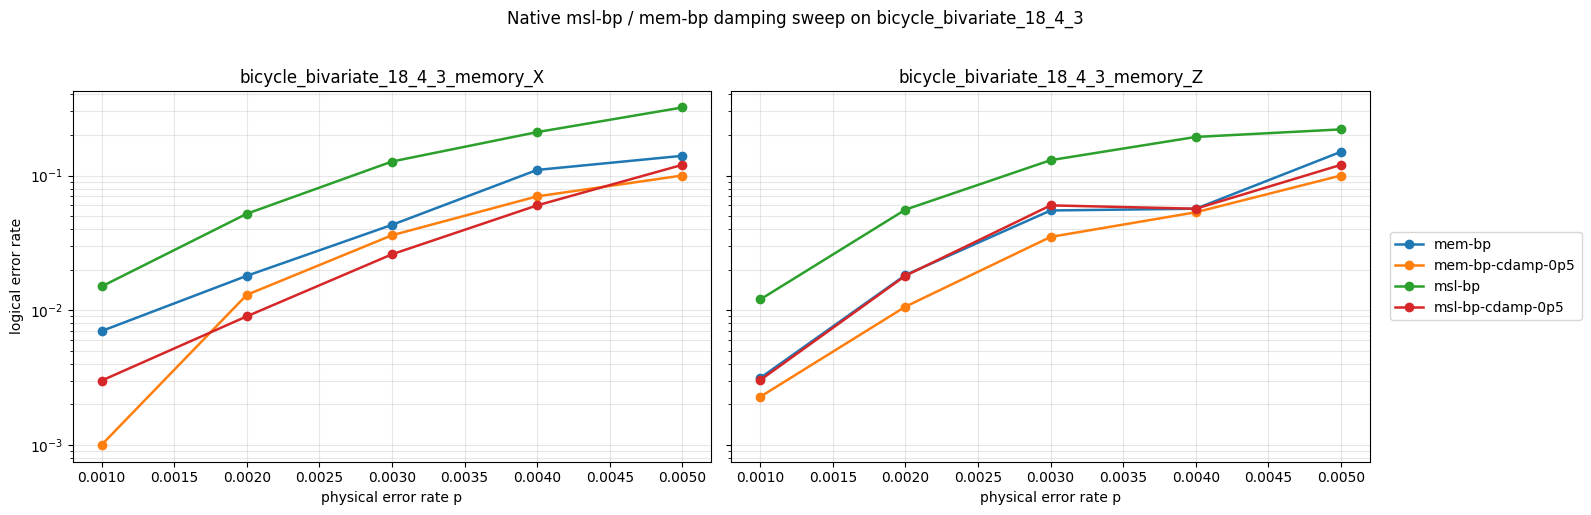

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

for ax, memory in zip(axes, ['X', 'Z']):
    memory_df = summary_df[summary_df['memory'] == memory]
    for decoder, group in memory_df.groupby('decoder'):
        group = group.sort_values('p')
        ax.plot(group['p'], group['ler'], marker='o', linewidth=1.8, label=decoder)
    ax.set_title(f'bicycle_bivariate_18_4_3_memory_{memory}')
    ax.set_xlabel('physical error rate p')
    ax.set_yscale('log')
    ax.grid(True, which='both', alpha=0.3)

axes[0].set_ylabel('logical error rate')
axes[1].legend(loc='center left', bbox_to_anchor=(1.02, 0.5))
fig.suptitle('Native msl-bp / mem-bp damping sweep on bicycle_bivariate_18_4_3', y=1.02)
fig.tight_layout()
plt.show()


,circuit,p_used,xz_check_shape,xyz_check_shape,xz_obs_shape,xyz_obs_shape,xz_detectors,xyz_detectors,xz_observables,xyz_observables,xz_check_nnz,xyz_check_nnz,stim_path
0,bicycle_bivariate_18_4_3_memory_X,0.001,"(36, 288)","(54, 1818)","(4, 288)","(4, 1818)",36,54,4,4,891,8874,C:\Users\User\Documents\projects-git\relay_mot...
1,bicycle_bivariate_18_4_3_memory_Z,0.001,"(36, 288)","(54, 1800)","(4, 288)","(4, 1800)",36,54,4,4,945,8910,C:\Users\User\Documents\projects-git\relay_mot...


: 